# Data Prep & Check

## 01. Imput & Load Data

In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm
%matplotlib inline

In [3]:
df = pd.read_csv(r"C:\Users\ALIENWARE\Desktop\Urban Data Informatics\PSet 03\202401-citibike-tripdata.csv")
df.head(2)

C:\Users\ALIENWARE\AppData\Local\Temp\ipykernel_18168\2491369128.py:1: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\ALIENWARE\Desktop\Urban Data Informatics\PSet 03\202401-citibike-tripdata.csv")


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,5078F3D302000BD2,electric_bike,2024-01-22 18:43:19.012,2024-01-22 18:48:10.708,Frederick Douglass Blvd & W 145 St,7954.12,St Nicholas Ave & W 126 St,7756.10,40.823072,-73.941738,40.811432,-73.951878,member
1,814337105D37302A,electric_bike,2024-01-11 19:19:18.721,2024-01-11 19:47:36.007,W 54 St & 6 Ave,6771.13,E 74 St & 1 Ave,6953.08,40.761822,-73.977036,40.768974,-73.954823,member


In [4]:
df['start_station_name'] = df['start_station_name'].astype(str)
df['end_station_name'] = df['end_station_name'].astype(str)

In [5]:
# Calcultae trip_duration in minutes
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

df['trip_duration'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60
df['trip_duration'] = df['trip_duration'].round().astype(int)
df.head(2)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration
0,5078F3D302000BD2,electric_bike,2024-01-22 18:43:19.012,2024-01-22 18:48:10.708,Frederick Douglass Blvd & W 145 St,7954.12,St Nicholas Ave & W 126 St,7756.10,40.823072,-73.941738,40.811432,-73.951878,member,5
1,814337105D37302A,electric_bike,2024-01-11 19:19:18.721,2024-01-11 19:47:36.007,W 54 St & 6 Ave,6771.13,E 74 St & 1 Ave,6953.08,40.761822,-73.977036,40.768974,-73.954823,member,28


In [6]:
df["coordinates_start"] = list(zip(df.start_lng,df.start_lat))
df["coordinates_end"] = list(zip(df.end_lng,df.start_lat))

df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration,coordinates_start,coordinates_end
0,5078F3D302000BD2,electric_bike,2024-01-22 18:43:19.012,2024-01-22 18:48:10.708,Frederick Douglass Blvd & W 145 St,7954.12,St Nicholas Ave & W 126 St,7756.10,40.823072,-73.941738,40.811432,-73.951878,member,5,"(-73.941738367, 40.823071718)","(-73.9518776, 40.823071718)"
1,814337105D37302A,electric_bike,2024-01-11 19:19:18.721,2024-01-11 19:47:36.007,W 54 St & 6 Ave,6771.13,E 74 St & 1 Ave,6953.08,40.761822,-73.977036,40.768974,-73.954823,member,28,"(-73.977036119, 40.761822224)","(-73.95482273, 40.761822224)"
2,A33A920E2B10710C,electric_bike,2024-01-30 19:17:41.693,2024-01-30 19:32:49.857,E 11 St & Ave B,5659.11,W 10 St & Washington St,5847.06,40.727592,-73.979751,40.733424,-74.008515,casual,15,"(-73.979750872, 40.72759223)","(-74.00851495563984, 40.72759223)"
3,A3A5FC0DD7D34D74,electric_bike,2024-01-27 11:27:01.759,2024-01-27 11:38:01.213,W 54 St & 6 Ave,6771.13,E 74 St & 1 Ave,6953.08,40.761779,-73.977144,40.768974,-73.954823,member,11,"(-73.977144361, 40.761778593)","(-73.95482273, 40.761778593)"
4,6F96728ECEFBDAA4,electric_bike,2024-01-16 15:15:41.000,2024-01-16 15:29:26.156,Madison Ave & E 99 St,7443.01,E 74 St & 1 Ave,6953.08,40.789808,-73.952214,40.768974,-73.954823,member,14,"(-73.952213883, 40.789807916)","(-73.95482273, 40.789807916)"


In [7]:
df['coordinates_start'] = df['coordinates_start'].apply(Point)
start_gdf = gpd.GeoDataFrame(df, geometry='coordinates_start')

In [8]:
start_gdf.head(3)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration,coordinates_start,coordinates_end
0,5078F3D302000BD2,electric_bike,2024-01-22 18:43:19.012,2024-01-22 18:48:10.708,Frederick Douglass Blvd & W 145 St,7954.12,St Nicholas Ave & W 126 St,7756.10,40.823072,-73.941738,40.811432,-73.951878,member,5,POINT (-73.94174 40.82307),"(-73.9518776, 40.823071718)"
1,814337105D37302A,electric_bike,2024-01-11 19:19:18.721,2024-01-11 19:47:36.007,W 54 St & 6 Ave,6771.13,E 74 St & 1 Ave,6953.08,40.761822,-73.977036,40.768974,-73.954823,member,28,POINT (-73.97704 40.76182),"(-73.95482273, 40.761822224)"
2,A33A920E2B10710C,electric_bike,2024-01-30 19:17:41.693,2024-01-30 19:32:49.857,E 11 St & Ave B,5659.11,W 10 St & Washington St,5847.06,40.727592,-73.979751,40.733424,-74.008515,casual,15,POINT (-73.97975 40.72759),"(-74.00851495563984, 40.72759223)"


<Axes: >

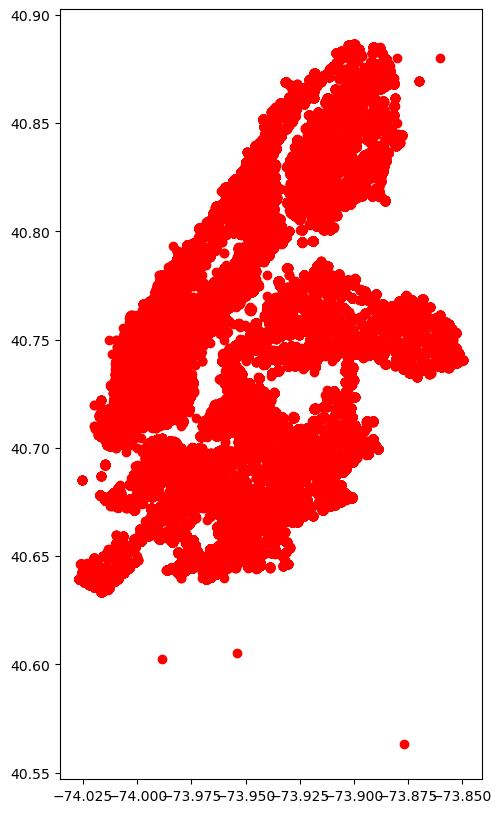

In [9]:
start_gdf.plot(figsize=(10, 10),color='red')

## 02. Data Cleaning & Filtering for Manhattan

In [10]:
# now, I want to be focus solely on Mnahattan 
manhattan_lat_range = (40.700292, 40.877483)
manhattan_lon_range = (-74.047285, -73.906158)

# Filter the DataFrame to keep only rows within Manhattan's boundaries
df_manhattan = df[
    (df['start_lat'].between(*manhattan_lat_range)) &
    (df['start_lng'].between(*manhattan_lon_range)) &
    (df['end_lat'].between(*manhattan_lat_range)) &
    (df['end_lng'].between(*manhattan_lon_range))
]

df_manhattan.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration,coordinates_start,coordinates_end
0,5078F3D302000BD2,electric_bike,2024-01-22 18:43:19.012,2024-01-22 18:48:10.708,Frederick Douglass Blvd & W 145 St,7954.12,St Nicholas Ave & W 126 St,7756.10,40.823072,-73.941738,40.811432,-73.951878,member,5,POINT (-73.941738367 40.823071718),"(-73.9518776, 40.823071718)"
1,814337105D37302A,electric_bike,2024-01-11 19:19:18.721,2024-01-11 19:47:36.007,W 54 St & 6 Ave,6771.13,E 74 St & 1 Ave,6953.08,40.761822,-73.977036,40.768974,-73.954823,member,28,POINT (-73.977036119 40.761822224),"(-73.95482273, 40.761822224)"
2,A33A920E2B10710C,electric_bike,2024-01-30 19:17:41.693,2024-01-30 19:32:49.857,E 11 St & Ave B,5659.11,W 10 St & Washington St,5847.06,40.727592,-73.979751,40.733424,-74.008515,casual,15,POINT (-73.979750872 40.72759223),"(-74.00851495563984, 40.72759223)"
3,A3A5FC0DD7D34D74,electric_bike,2024-01-27 11:27:01.759,2024-01-27 11:38:01.213,W 54 St & 6 Ave,6771.13,E 74 St & 1 Ave,6953.08,40.761779,-73.977144,40.768974,-73.954823,member,11,POINT (-73.977144361 40.761778593),"(-73.95482273, 40.761778593)"
4,6F96728ECEFBDAA4,electric_bike,2024-01-16 15:15:41.000,2024-01-16 15:29:26.156,Madison Ave & E 99 St,7443.01,E 74 St & 1 Ave,6953.08,40.789808,-73.952214,40.768974,-73.954823,member,14,POINT (-73.952213883 40.789807916),"(-73.95482273, 40.789807916)"


In [11]:
df_manhattan.to_csv(r"C:\Users\ALIENWARE\Desktop\Urban Data Informatics\PSet 03\citibike_manhattan.csv", index=False)

C:\Users\ALIENWARE\AppData\Local\Temp\ipykernel_18168\1668020396.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_manhattan['coordinates_start'] = df_manhattan['coordinates_start'].apply(Point)


<Axes: >

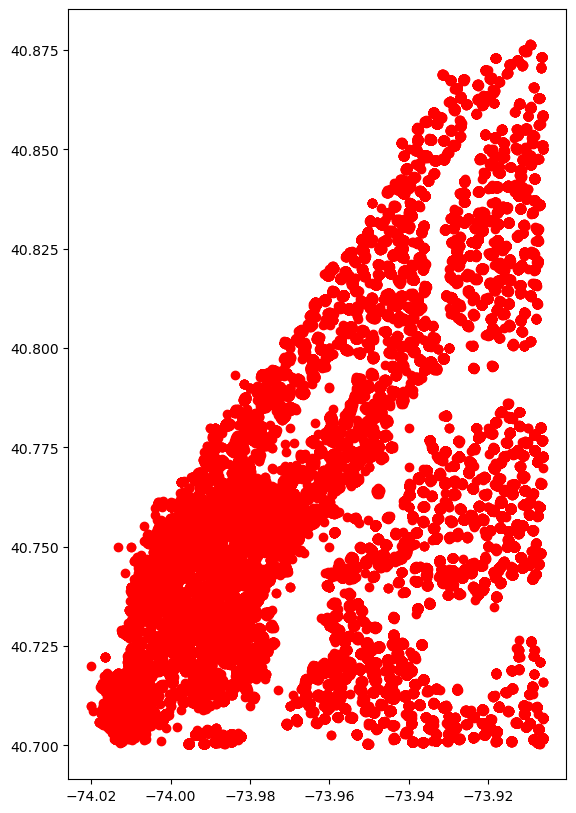

In [12]:
df_manhattan['coordinates_start'] = df_manhattan['coordinates_start'].apply(Point)
df_manhattan_gdf = gpd.GeoDataFrame(df_manhattan, geometry='coordinates_start')

df_manhattan_gdf.plot(figsize=(10, 10),color='red')

# Data Analysis 

## 01. Usage Duration 

In [19]:
#calculate the mean trip-duration 
df_manhattan['trip_duration'].mean()

10.716621934142774

In [27]:
avg_duration_by_bike = df_manhattan.groupby('rideable_type')['trip_duration'].mean()
avg_duration_by_bike

rideable_type
classic_bike     11.504002
electric_bike    10.262558
Name: trip_duration, dtype: float64

In [31]:
#Trip distance from start to end points
df_manhattan = df_manhattan.copy()
df_manhattan['trip_distance'] = df_manhattan.apply(lambda row: geodesic(
    (row['start_lat'], row['start_lng']), 
    (row['end_lat'], row['end_lng'])).kilometers, axis=1)

In [33]:
avg_distance_by_bike = df_manhattan.groupby('rideable_type')['trip_distance'].mean()
avg_distance_by_bike

rideable_type
classic_bike     1.409791
electric_bike    1.843328
Name: trip_distance, dtype: float64

## 02. Spatial Analysis Prep

In [36]:
boros = gpd.read_file(r'C:\Users\ALIENWARE\Desktop\Urban Data Informatics\PSet 03\boros.geojson')

In [37]:
boros.head()

,OBJECTID,BoroCode,BoroName,CountyFIPS,NTACode,NTAName,Shape__Area,Shape__Length,geometry
0,1,3,Brooklyn,047,BK88,Borough Park,5.400502e+07,39247.228028,"POLYGON ((-73.97605 40.63128, -73.97717 40.630..."
1,2,4,Queens,081,QN51,Murray Hill,5.248828e+07,33266.904861,"POLYGON ((-73.80379 40.77562, -73.80099 40.775..."
2,3,4,Queens,081,QN27,East Elmhurst,1.972695e+07,19816.685003,"POLYGON ((-73.8611 40.76367, -73.85993 40.7622..."
3,4,4,Queens,081,QN07,Hollis,2.288777e+07,20976.335574,"POLYGON ((-73.75726 40.71815, -73.75589 40.716..."
4,5,1,Manhattan,061,MN06,Manhattanville,1.064708e+07,17040.685413,"POLYGON ((-73.94608 40.82127, -73.9464 40.8205..."


In [38]:
print (boros.crs)
print (boros.crs.name)
print (boros.crs.datum)

EPSG:4326
WGS 84
World Geodetic System 1984 ensemble


In [39]:
boros.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [44]:
print(df_manhattan_gdf.crs)

None


In [45]:
df_manhattan_gdf.set_crs(epsg=4326, inplace=True)
df_manhattan_gdf = df_manhattan_gdf.to_crs(epsg=2263)

In [47]:
boros = boros.to_crs("EPSG:2263")

In [48]:
print (boros.crs)
print (df_manhattan_gdf.crs)

EPSG:2263
EPSG:2263


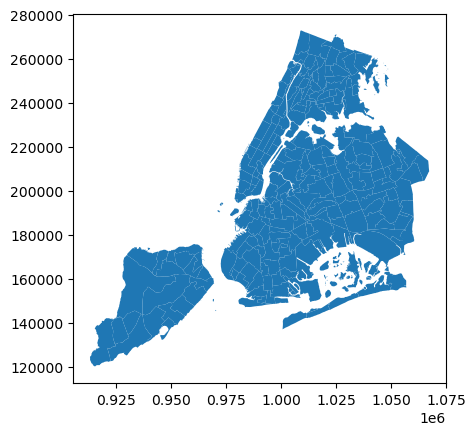

In [49]:
boros.plot()
plt.show()

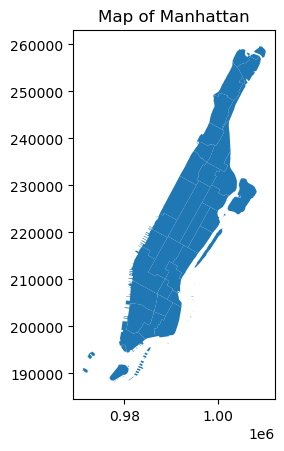

In [55]:
# Filter the GeoDataFrame to keep only rows where the BoroName is "Manhattan"
manhattan = boros[boros['BoroName'] == 'Manhattan']

# Optionally, plot the filtered GeoDataFrame to check the Manhattan boundaries
manhattan.plot()
plt.title("Map of Manhattan")
plt.show()

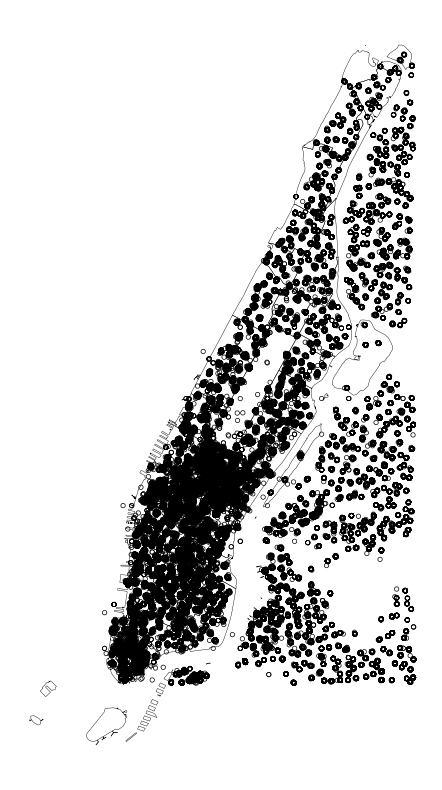

In [56]:
base = manhattan.plot(figsize=(10,10), linewidth=0.3, edgecolor='k', facecolor='none')
df_manhattan_gdf.plot(ax=base, markersize = 10, color = 'none', edgecolor='k', linewidth=0.5)


plt.axis(False)
plt.show()

## 03. Spatial Join

In [62]:
# Convert both GeoDataFrames to the same CRS
gdf_citibike = gdf_citibike.to_crs("EPSG:4326")
manhattan_gdf = manhattan_gdf.to_crs("EPSG:4326")
print(gdf_citibike[['start_lat', 'start_lng', 'start_point']].head())

   start_lat  start_lng                 start_point
0  40.823072 -73.941738  POINT (-73.94174 40.82307)
1  40.761822 -73.977036  POINT (-73.97704 40.76182)
2  40.727592 -73.979751  POINT (-73.97975 40.72759)
3  40.761779 -73.977144  POINT (-73.97714 40.76178)
4  40.789808 -73.952214  POINT (-73.95221 40.78981)


In [65]:
# Convert the Citi Bike start points to a GeoDataFrame if it’s not already
# Assuming df_manhattan has columns 'start_latitude' and 'start_longitude'
df_manhattan['start_point'] = df_manhattan.apply(lambda row: Point(row['start_lng'], row['start_lat']), axis=1)
gdf_citibike = gpd.GeoDataFrame(df_manhattan, geometry='start_point', crs="EPSG:4326")

# Perform a spatial join to keep only points within the Manhattan boundary
# 'inner' join ensures only points within the boundary are kept
citibike_manhattan = gpd.sjoin(gdf_citibike, manhattan_gdf, how="inner", predicate="within")

# Drop any unnecessary columns that were added from the join (optional)
citibike_manhattan = citibike_manhattan.drop(columns=['index_right'])

citibike_manhattan.head(5)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,trip_distance,start_point,OBJECTID,BoroCode,BoroName,CountyFIPS,NTACode,NTAName,Shape__Area,Shape__Length
0,5078F3D302000BD2,electric_bike,2024-01-22 18:43:19.012,2024-01-22 18:48:10.708,Frederick Douglass Blvd & W 145 St,7954.12,St Nicholas Ave & W 126 St,7756.10,40.823072,-73.941738,...,1.549986,POINT (-73.94174 40.82307),151,1,Manhattan,061,MN03,Central Harlem North-Polo Grounds,2.540349e+07,27983.841389
1,814337105D37302A,electric_bike,2024-01-11 19:19:18.721,2024-01-11 19:47:36.007,W 54 St & 6 Ave,6771.13,E 74 St & 1 Ave,6953.08,40.761822,-73.977036,...,2.036753,POINT (-73.97704 40.76182),107,1,Manhattan,061,MN17,Midtown-Midtown South,3.019157e+07,27032.582981
2,A33A920E2B10710C,electric_bike,2024-01-30 19:17:41.693,2024-01-30 19:32:49.857,E 11 St & Ave B,5659.11,W 10 St & Washington St,5847.06,40.727592,-73.979751,...,2.514721,POINT (-73.97975 40.72759),174,1,Manhattan,061,MN22,East Village,1.089432e+07,13555.239450
3,A3A5FC0DD7D34D74,electric_bike,2024-01-27 11:27:01.759,2024-01-27 11:38:01.213,W 54 St & 6 Ave,6771.13,E 74 St & 1 Ave,6953.08,40.761779,-73.977144,...,2.047059,POINT (-73.97714 40.76178),107,1,Manhattan,061,MN17,Midtown-Midtown South,3.019157e+07,27032.582981
4,6F96728ECEFBDAA4,electric_bike,2024-01-16 15:15:41.000,2024-01-16 15:29:26.156,Madison Ave & E 99 St,7443.01,E 74 St & 1 Ave,6953.08,40.789808,-73.952214,...,2.324079,POINT (-73.95221 40.78981),190,1,Manhattan,061,MN33,East Harlem South,1.665069e+07,18624.664753


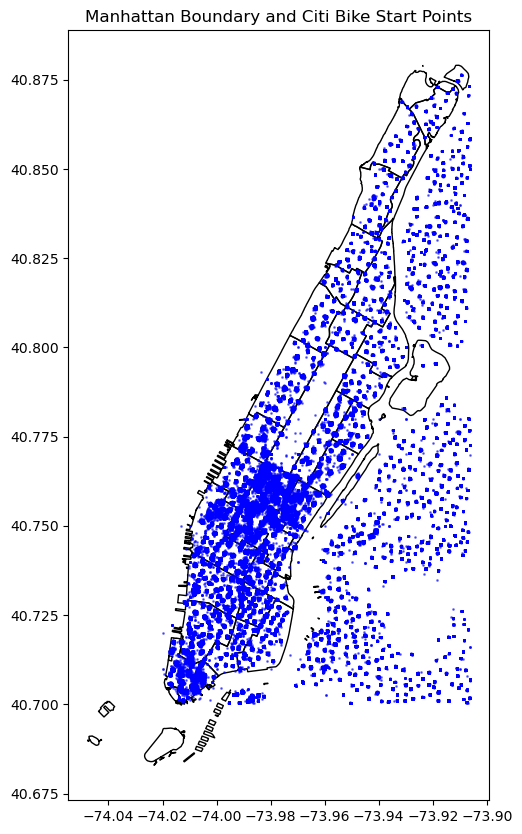

In [67]:
# Plot both layers to confirm alignment
ax = manhattan_gdf.plot(edgecolor='k', color='none', figsize=(10, 10))
gdf_citibike.plot(ax=ax, color='blue', markersize=1, alpha=0.5)
plt.title("Manhattan Boundary and Citi Bike Start Points")
plt.show()

## 04. Create choropleth maps

In [70]:
# Calculate bike density (based on start point) & avg trip duration for each neighborhood
bike_density = citibike_manhattan.groupby("NTAName").size().reset_index(name="bike_density")
avg_trip_duration = citibike_manhattan.groupby("NTAName")["trip_duration"].mean().reset_index(name="avg_trip_duration")
manhattan_neighborhoods = manhattan.merge(bike_density, on="NTAName").merge(avg_trip_duration, on="NTAName")

In [80]:
# Set dynamic vmin and vmax
vmin = manhattan_neighborhoods['bike_density'].min()
vmax = manhattan_neighborhoods['bike_density'].max()

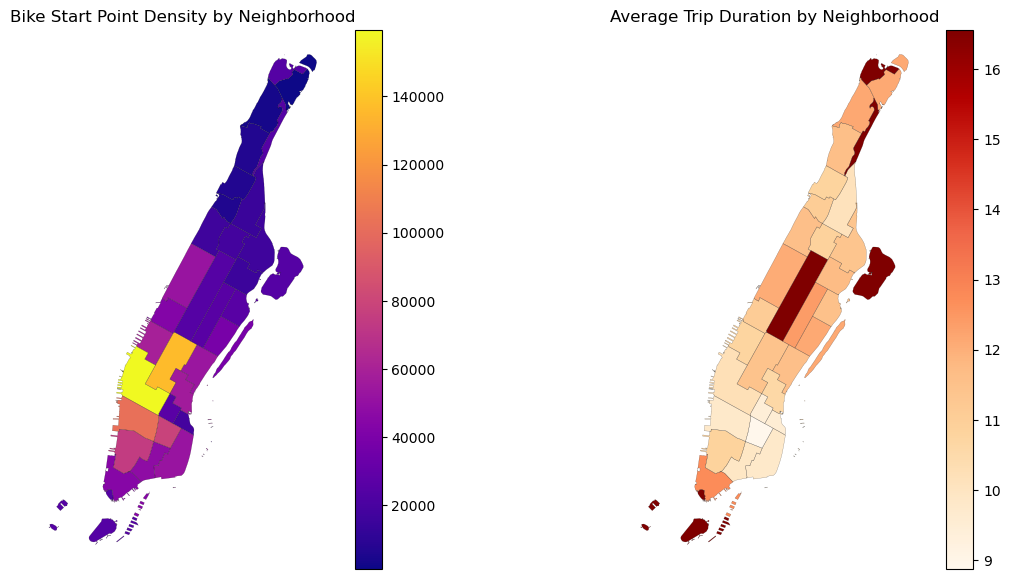

In [81]:
# Plot Choropleth Maps for Bike Density and Average Trip Duration
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

#Plot for bike Density 
manhattan_neighborhoods.boundary.plot(linewidth=0.2, edgecolor='k', alpha=0.5, ax=ax[0])
manhattan_neighborhoods.plot(column='bike_density', ax=ax[0], cmap='plasma', legend=True, vmin=vmin, vmax=vmax)
ax[0].set_title("Bike Start Point Density by Neighborhood")
ax[0].axis("off")

# Plot for Average Trip Duration 
vmin_duration = manhattan_neighborhoods['avg_trip_duration'].min()
m_max_duration = manhattan_neighborhoods['avg_trip_duration'].max()

manhattan_neighborhoods.boundary.plot(linewidth=0.2, edgecolor='k', alpha=0.5, ax=ax[1])
manhattan_neighborhoods.plot(column='avg_trip_duration', ax=ax[1], cmap='OrRd', legend=True, vmin=vmin_duration, vmax=vmax_duration)
ax[1].set_title("Average Trip Duration by Neighborhood")
ax[1].axis("off")

plt.show()

## 05. Temporal Variations

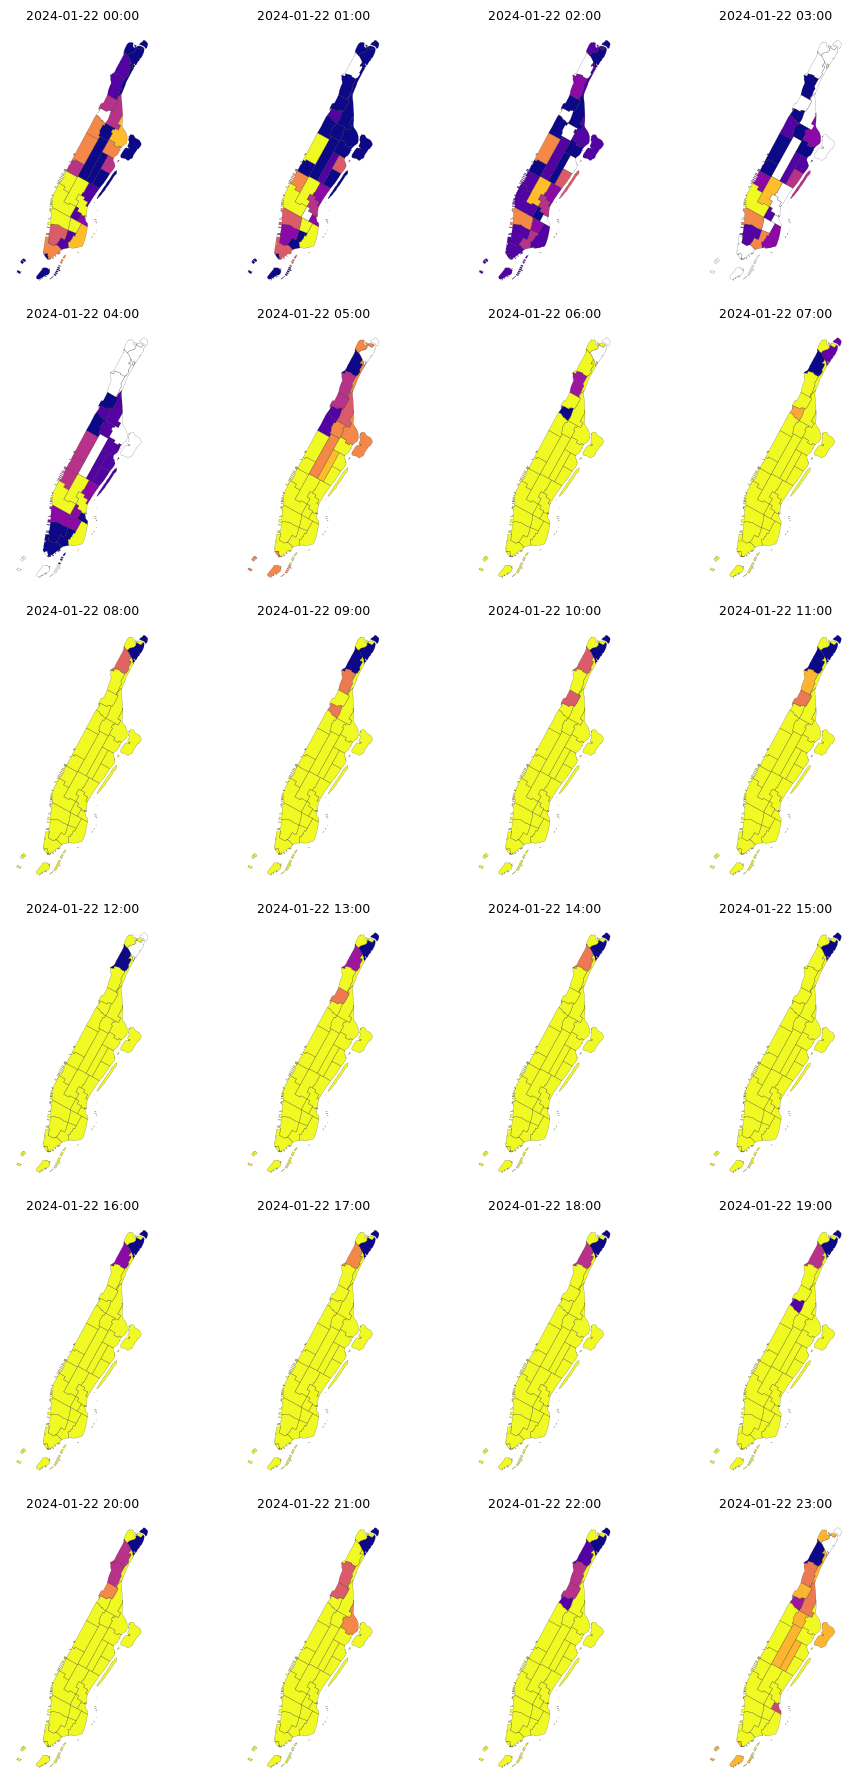

In [112]:
# Define date and time range
start_datetime = pd.to_datetime("2024-01-22 00:00:00")
end_datetime = pd.to_datetime("2024-01-22 23:59:59")

# Extract unique hourly timestamps
date_hour_list = (
    citibike_manhattan['started_at']
    .dt.floor('h')
    .unique()
    .tolist()
)

date_hour_list = sorted([dt for dt in date_hour_list if start_datetime <= dt <= end_datetime])

# Create a subplot grid based on the number of filtered time segments
nrows = (len(date_hour_list) + 3) // 4  # Adjust number of rows based on filtered date_hour_list
fig, ax = plt.subplots(figsize=(10, nrows * 3), ncols=4, nrows=nrows)
ax = ax.flatten()

# Loop through each filtered hour and plot bike density
for i, segment in enumerate(date_hour_list):
    # Filter data for the specific hour
    df_hour = citibike_manhattan[citibike_manhattan['started_at'].dt.floor('h') == segment]
    
    # Calculate hourly bike density per neighborhood
    bike_density_hour = df_hour.groupby("NTAName").size().reset_index(name="bike_density")
    
    # Merge with neighborhood boundaries for plotting
    nta_hour = manhattan_neighborhoods.merge(bike_density_hour, on="NTAName", how="left").fillna({"bike_density": 0})
    
    # Rename 'bike_density_y' to 'bike_density' for easier plotting
    nta_hour = nta_hour.rename(columns={"bike_density_y": "bike_density"})
    
    # Ensure bike_density is numeric to avoid plotting errors
    nta_hour['bike_density'] = pd.to_numeric(nta_hour['bike_density'])
    
    # Plot boundaries and bike density for this hour
    nta_hour.boundary.plot(ax=ax[i], linewidth=0.2, edgecolor='k', alpha=0.5)
    nta_hour.plot(ax=ax[i], column='bike_density', cmap='plasma', vmax=8)
    
    # Set title and formatting for each hour
    ax[i].axis(False)
    ax[i].set_title(segment.strftime('%Y-%m-%d %H:%M'), fontsize=9)

# Hide any unused subplots
for j in range(i + 1, len(ax)):
    ax[j].axis("off")

plt.tight_layout()
plt.show()